In [44]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

df.head()

df.columns


Index(['ParticipantID', 'Age', 'Location', 'DietType', 'LocalFoodFrequency',
       'TransportationMode', 'EnergySource', 'HomeType', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'Gender', 'UsingPlasticProducts',
       'DisposalMethods', 'PhysicalActivities', 'Rating'],
      dtype='object')

### See the apriori -example for the reasoning on how to handle these categories

In [45]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [46]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [47]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [48]:
df.isna().sum()

ParticipantID                          0
Age                                    0
LocalFoodFrequency                     0
HomeSize                               0
ClothingFrequency                      0
SustainableBrands                      0
EnvironmentalAwareness                 0
CommunityInvolvement                 118
MonthlyElectricityConsumption          0
MonthlyWaterConsumption                0
UsingPlasticProducts                  95
PhysicalActivities                   108
Rating                                 0
Location_Rural                         0
Location_Suburban                      0
Location_Urban                         0
DietType_Balanced                      0
DietType_Mostly Animal-Based           0
DietType_Mostly Plant-Based            0
TransportationMode_Bike                0
TransportationMode_Car                 0
TransportationMode_Public Transit      0
TransportationMode_Walk                0
EnergySource_Mixed                     0
EnergySource_Non

In [49]:
df.columns

Index(['ParticipantID', 'Age', 'LocalFoodFrequency', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'UsingPlasticProducts', 'PhysicalActivities',
       'Rating', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'DietType_Mostly Plant-Based', 'TransportationMode_Bike',
       'TransportationMode_Car', 'TransportationMode_Public Transit',
       'TransportationMode_Walk', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'EnergySource_Renewable',
       'HomeType_Apartment', 'HomeType_House', 'HomeType_Other',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'Gender_Prefer not to say', 'DisposalMethods_Combination',
       'DisposalMethods_Composting', 'DisposalMethods_Landfill',
       'DisposalMethods_Recycling'],
      dtype='object')

### Handle some missing values, these are highly assuming replacement values, but we don't have much data to work with.... probably something fancier should be used here

In [50]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [51]:
# replace missing community involvement with 0
# replace missing using plastic products with 3
# replace missing physical activities with 0


In [52]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [53]:
df.isna().sum().sum()

np.int64(0)

In [54]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0

In [55]:
df['Rating'] = df['Rating'].astype(int)
#df['Rating'] = "Class " + df['Rating'].astype(str)

In [56]:
df['Rating'].value_counts()

Rating
4    176
2    101
0     97
3     91
1     34
Name: count, dtype: int64

In [57]:
df.head()

,ParticipantID,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,1,35,2,800,0,1,5,2.0,100,1500,...,0,0,1,0,1,0,0,0,1,0
1,2,28,1,1500,1,1,4,1.0,250,3000,...,1,0,0,1,0,1,0,0,0,0
2,3,65,0,2500,2,0,2,0.0,400,4500,...,0,1,0,1,0,1,0,0,0,1
3,4,42,2,950,1,1,4,1.0,150,2000,...,0,0,1,0,1,0,0,0,0,0
4,5,31,1,1800,2,1,3,0.0,300,3500,...,1,0,0,1,0,0,1,1,0,0


**Binary classification needs changes to the further SHAP visualizations...**

In [58]:
# def convert_to_binary(row):
#     if row['Rating'] <= 1:
#         return 0
#     else:
#         return 1
    

# df['Rating'] = df.apply(convert_to_binary, axis=1)

## SHAP analysis, it's a bit different when it comes to classification

shap_values.values.shape: (100, 29, 5)
X_test.shape: (100, 29)


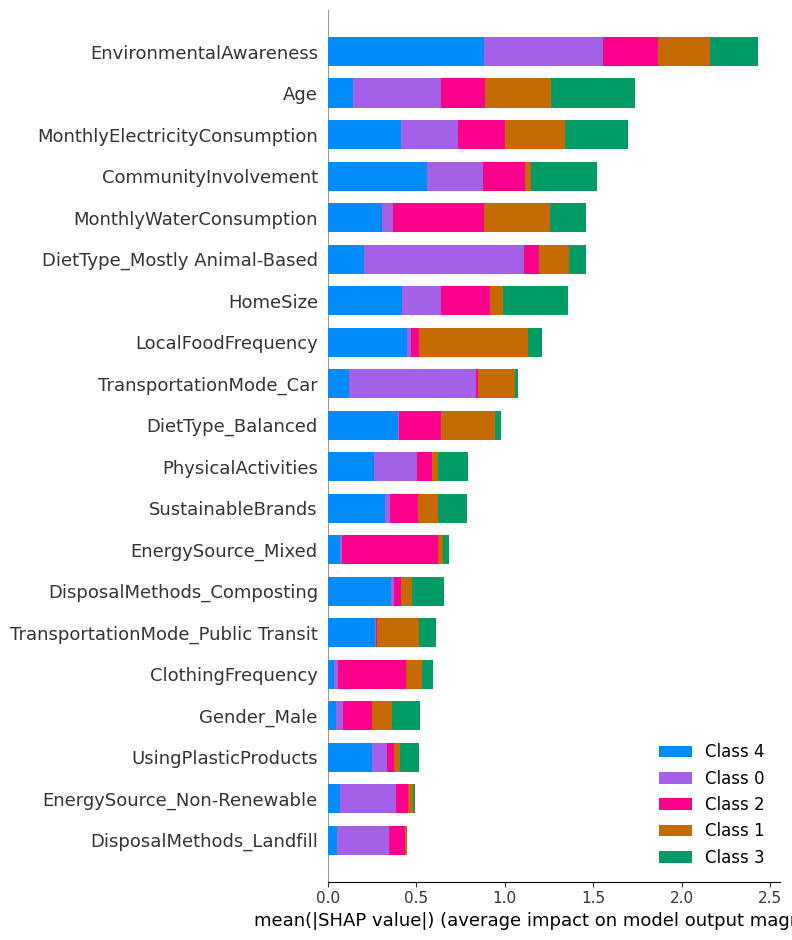

In [59]:
# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['ParticipantID'], axis=1)

# Define features and target
X = df.drop("Rating", axis=1)

y = df['Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# use GPU-enabled XGBoost Regressor
model = xgb.XGBClassifier(tree_method='gpu_hist', objective="multi:softproba", num_class=5)
# model = xgb.XGBClassifier(tree_method='gpu_hist', objective="binary:logistic", num_class=2)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

print("shap_values.values.shape:", shap_values.values.shape)
# Typically (n_samples, n_classes, n_features) = (30, 3, 4) for Iris
print("X_test.shape:", X_test.shape)

shap.summary_plot(shap_values, X_test)

___

### More experimental additional SHAP visualizations

Combination of AI, documentation and Googling


--- Beeswarm for class 0 ---


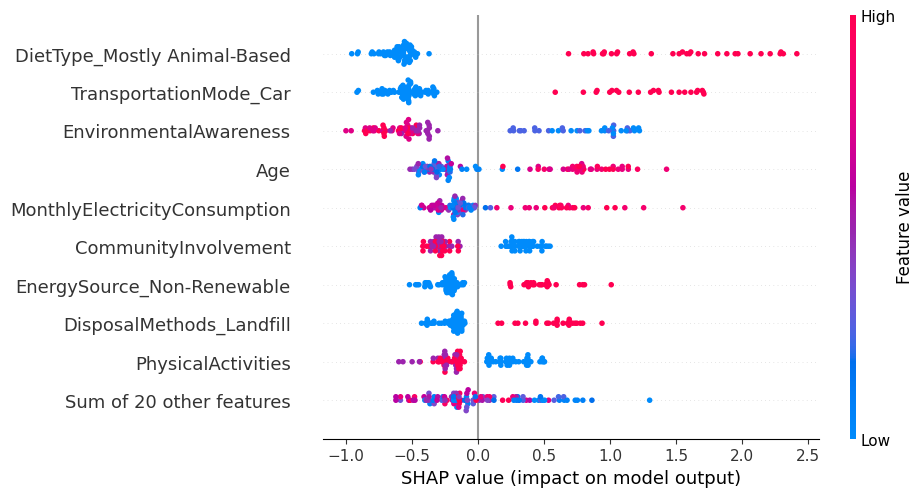


--- Beeswarm for class 1 ---


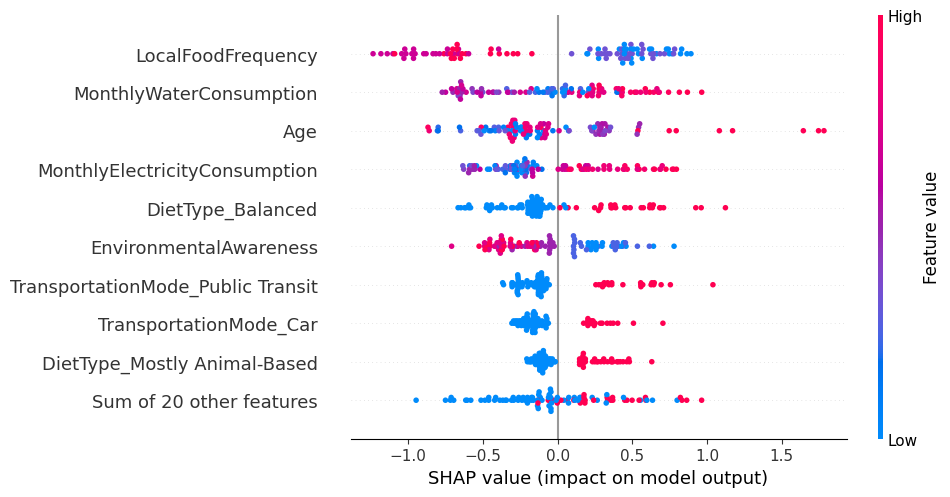


--- Beeswarm for class 2 ---


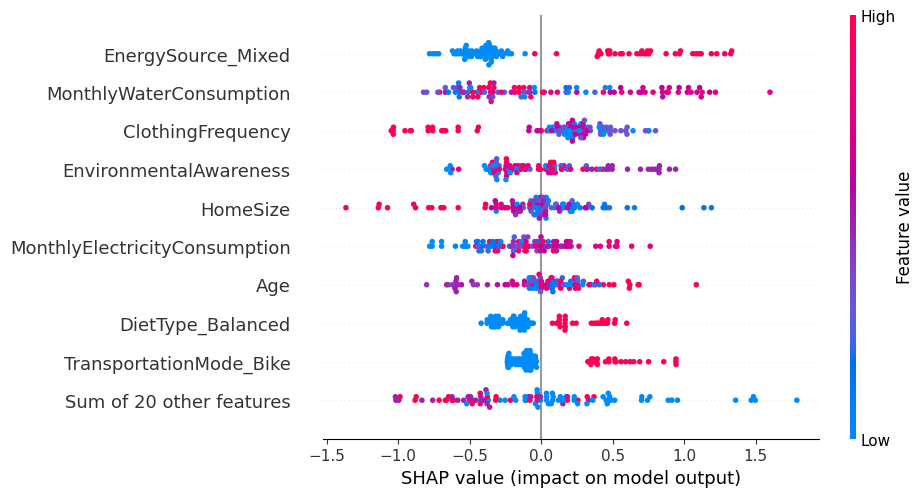


--- Beeswarm for class 3 ---


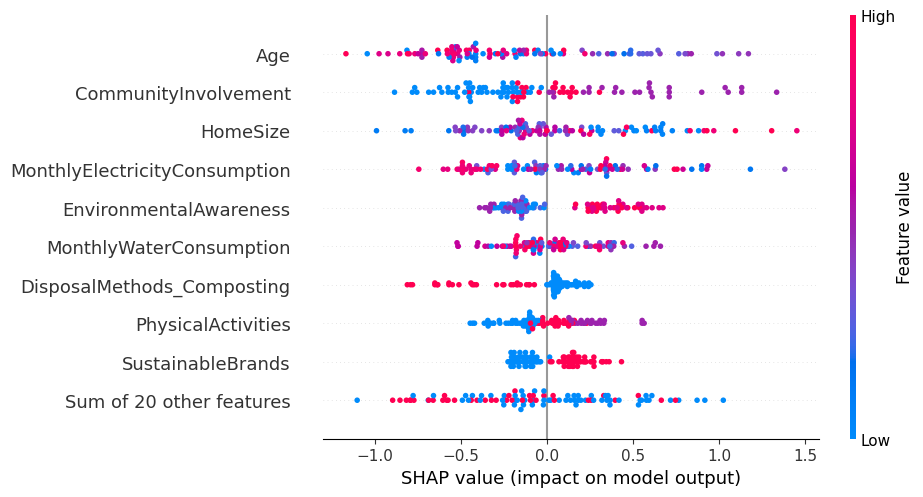


--- Beeswarm for class 4 ---


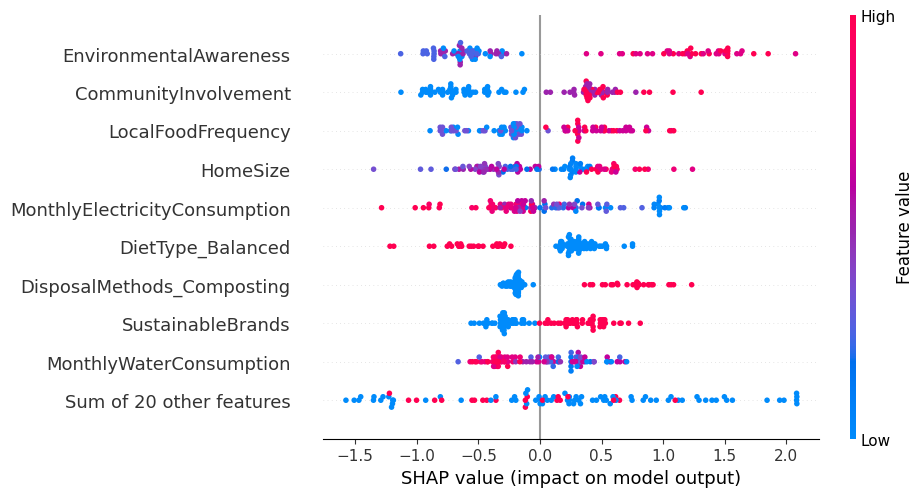

In [60]:
num_classes = shap_values.values.shape[1]
for class_idx in range(5):
    # Extract Explanation object for this class only
    shap_values_class = shap_values[..., class_idx]
    print(f"\n--- Beeswarm for class {class_idx} ---")
    shap.plots.beeswarm(shap_values_class)


--- Bar plot for class 0 ---


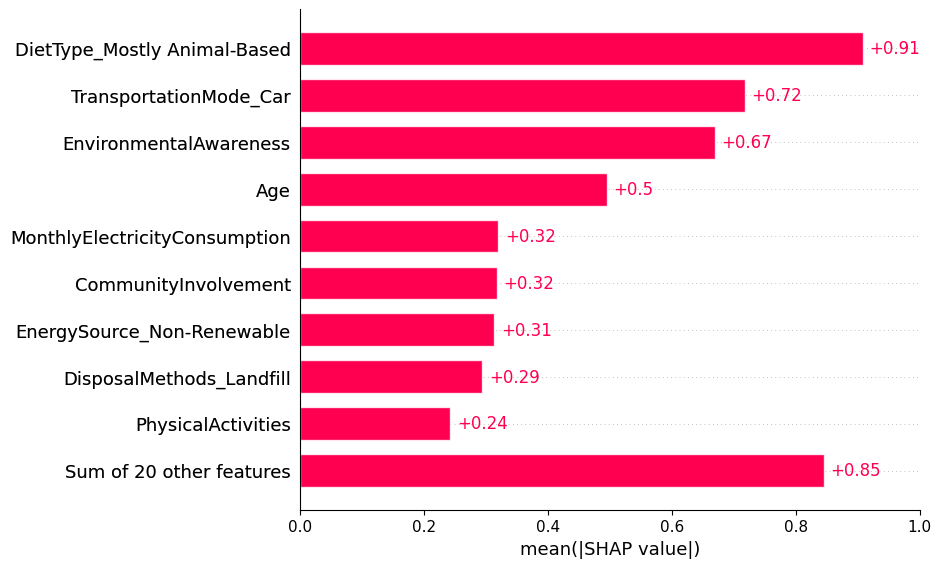


--- Bar plot for class 1 ---


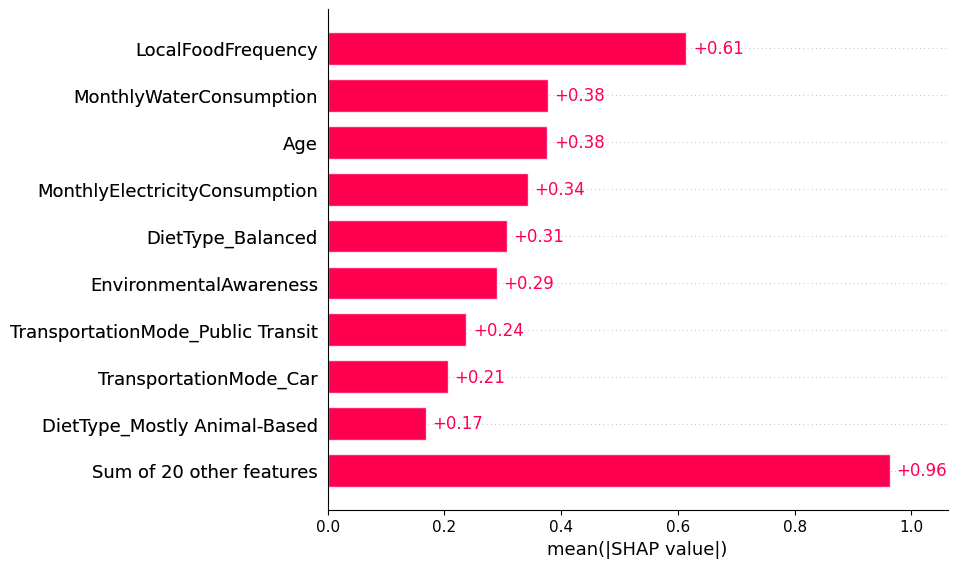


--- Bar plot for class 2 ---


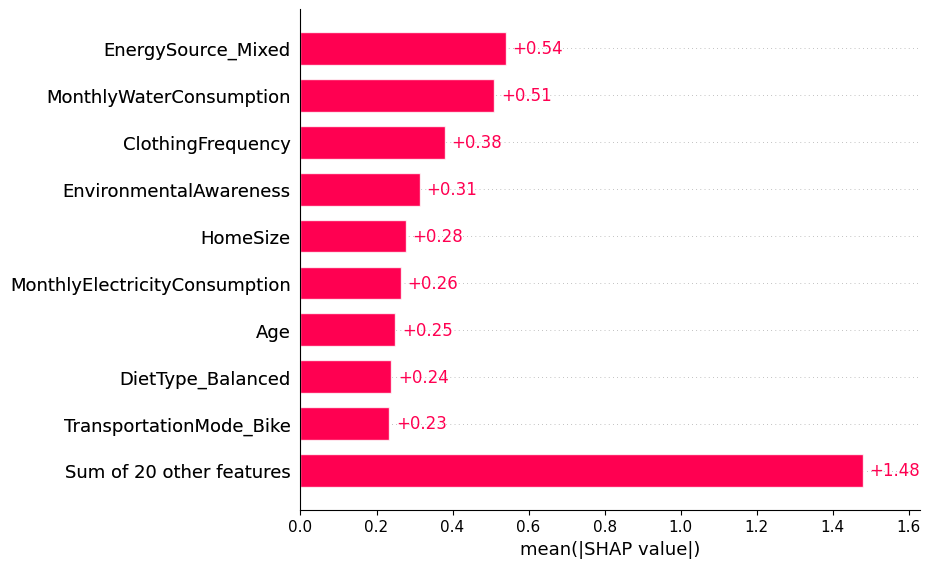


--- Bar plot for class 3 ---


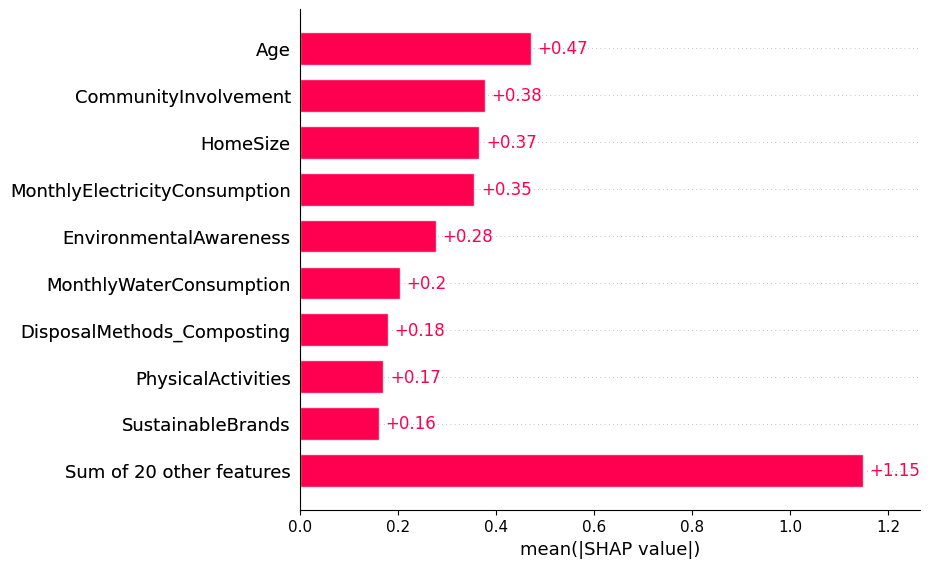


--- Bar plot for class 4 ---


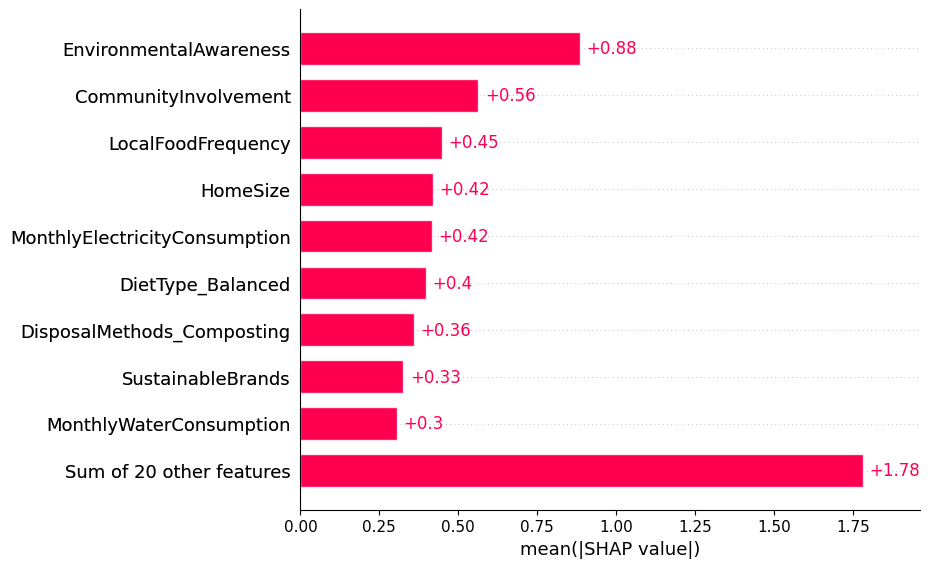

In [61]:
num_classes = shap_values.values.shape[1]
for class_idx in range(5):
    # Extract Explanation object for this class only
    shap_values_class = shap_values[..., class_idx]
    print(f"\n--- Bar plot for class {class_idx} ---")
   
    shap.plots.bar(shap_values_class)

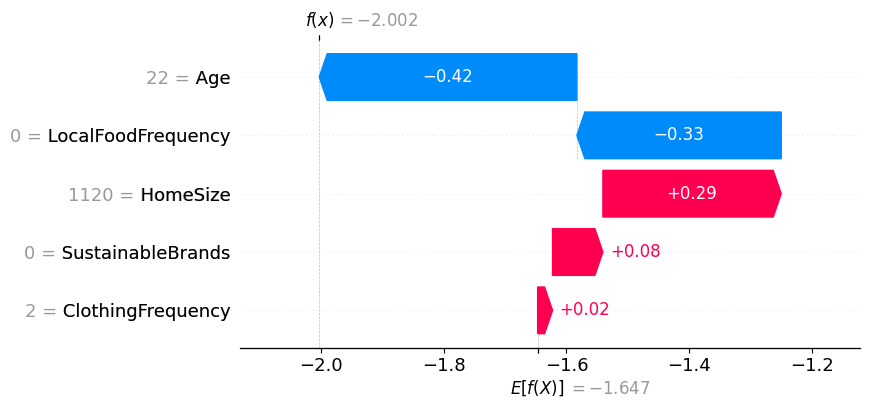

In [62]:
import shap

# Pick a sample index and class
sample_idx = 0
class_idx = 0

# Extract values & base_values explicitly
vals = shap_values.values[sample_idx, class_idx]
base_val = shap_values.base_values[sample_idx, class_idx]
data = shap_values.data[sample_idx]

# Construct a new Explanation object explicitly
single_exp = shap.Explanation(
    values=vals,
    base_values=base_val,
    data=data,
    feature_names=shap_values.feature_names
)

shap.plots.waterfall(single_exp)


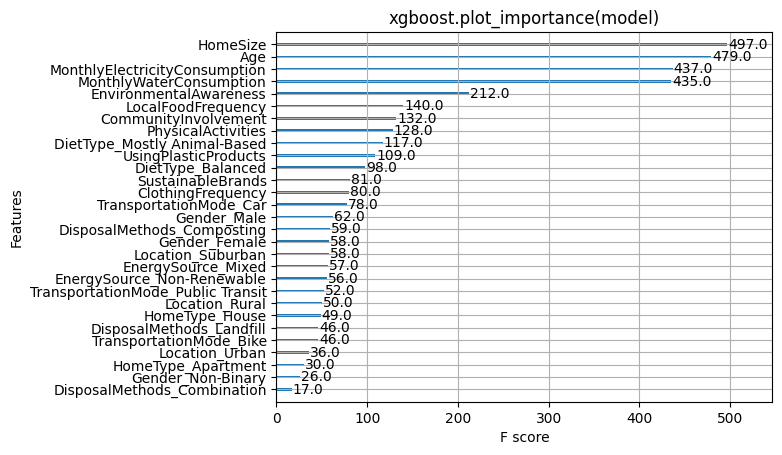

In [63]:
# XGBoost has a built-in importance feature too
xgb.plot_importance(model)
plt.title("xgboost.plot_importance(model)")
plt.show()

In [64]:
# Class index to explain (e.g., class 0)
class_idx = 0

shap.initjs()

shap.plots.force(
    base_value=shap_values.base_values[0][class_idx],
    shap_values=shap_values.values[0, :, class_idx],
    features=X_test.iloc[0],
    feature_names=list(X_test.columns)
)


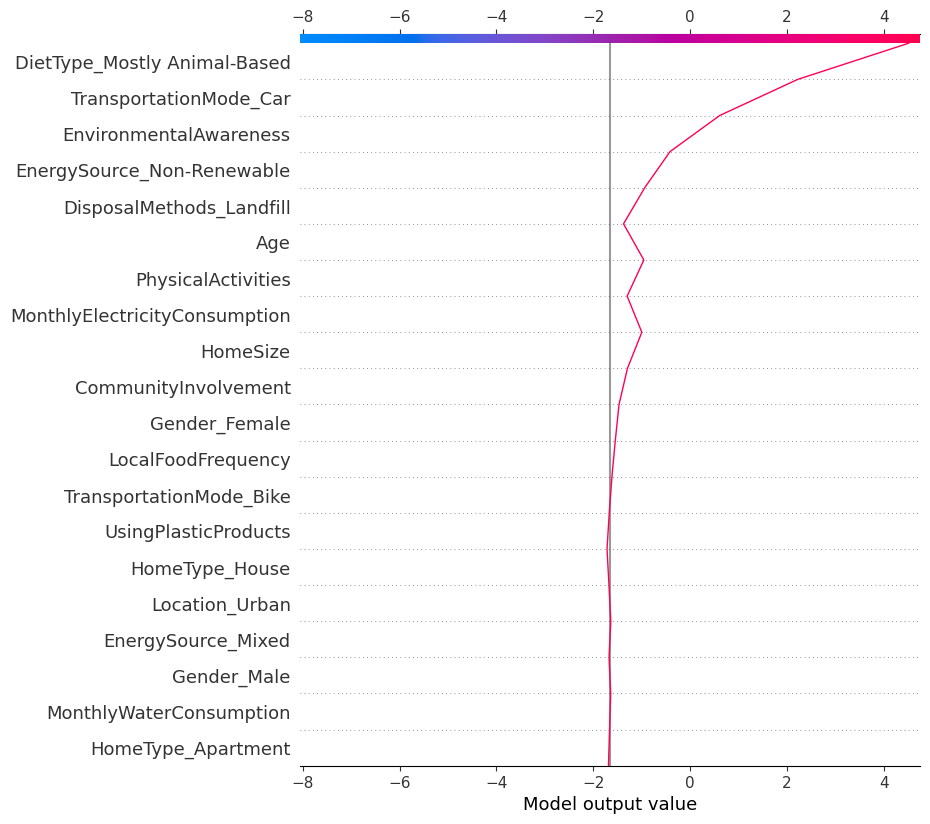

In [65]:
# Class index to explain (e.g., class 0)
class_idx = 0

shap.initjs()

shap.plots.decision(
    base_value=shap_values.base_values[0][class_idx],
    shap_values=shap_values.values[0, :, class_idx],
    feature_names=list(X_test.columns),
)


**This plot looks promising, but might have bugs, not thoroughly tested**

You have to be careful when using these, pay attention to which variables you compare AND WHICH TARGET CLASS ARE YOU COMPARING TO

In [66]:
# import matplotlib.pyplot as plt

# feature_1 = 'MonthlyElectricityConsumption'
# feature_2 = 'MonthlyWaterConsumption'

# class_idx = 0  # class to inspect (0 to 4)

# # # Use TreeExplainer specifically for XGBoost
# explainer = shap.TreeExplainer(model)

# feature_names = X_train.columns

# # Subset X_test to these features to be sure of order
# X_test_subset = X_test[feature_names]

# # Get feature indices
# i = feature_names.get_loc(feature_1)
# j = feature_names.get_loc(feature_2)

# shap_interaction_values = explainer.shap_interaction_values(X_test_subset)

# # interaction array shape: (samples, feat1, feat2, classes)
# # Pick class index on last axis
# interaction_vals = shap_interaction_values[:, i, j, class_idx]

# # Plot
# plt.figure(figsize=(8,6))
# scatter = plt.scatter(
#     X_test_subset[feature_1],  # x-axis: feature 1 values
#     interaction_vals,          # y-axis: interaction SHAP values
#     c=X_test_subset[feature_2],# color by feature 2 values
#     cmap='coolwarm',
#     alpha=0.7
# )

# plt.xlabel(feature_1)
# plt.ylabel(f'SHAP Interaction with {feature_2} for class {class_idx}')
# plt.colorbar(scatter, label=feature_2)
# plt.title(f'SHAP Interaction values between {feature_1} and {feature_2} for class {class_idx}')
# plt.show()


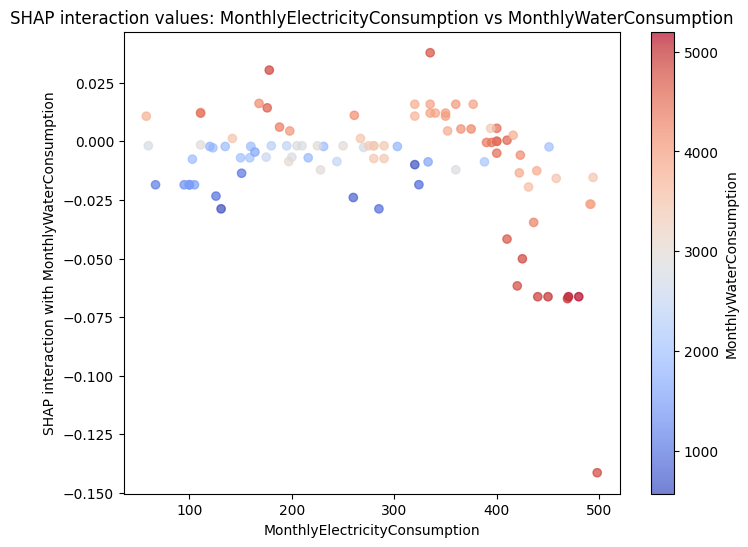

In [67]:
# a more simple version of the code above...
# needs still more testing if this actually works. 
# probably would be easiest to have a much more simple dataset
# and to test how it behaves here
import matplotlib.pyplot as plt

feature_1 = 'MonthlyElectricityConsumption'
feature_2 = 'MonthlyWaterConsumption'

explainer = shap.TreeExplainer(model)

class_idx = 0  # class to inspect (0 to 4)

shap_interaction_values = explainer.shap_interaction_values(X_test)

# Indices of the two features
i = X_test.columns.get_loc(feature_1)
j = X_test.columns.get_loc(feature_2)

# Extract values
interaction_vals = shap_interaction_values[:, i, j, class_idx]
feat1_vals = X_test.iloc[:, i]
feat2_vals = X_test.iloc[:, j]

# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(feat1_vals, interaction_vals, c=feat2_vals, cmap='coolwarm', alpha=0.7)
plt.xlabel(feature_1)
plt.ylabel('SHAP interaction with ' + feature_2)
plt.colorbar(sc, label=feature_2)
plt.title(f'SHAP interaction values: {feature_1} vs {feature_2}')
plt.show()


### Another version, dependence plot => basically interaction plot but in addition to interaction between variables, also their combined effect to target variable!

In [68]:
# import matplotlib.pyplot as plt

# class_idx = 4  # class to inspect (0 to 4)

# feature_names = X_train.columns

# # Subset X_test to these features to be sure of order
# X_test_subset = X_test[feature_names]

# # Indices of features
# i = feature_names.get_loc(feature_1)
# j = feature_names.get_loc(feature_2)

# # Extract SHAP interaction values for class
# interaction_values = shap_interaction_values[:, i, j, class_idx]

# # Extract main effect SHAP values for feature_1
# main_effect_values = shap_interaction_values[:, i, i, class_idx]

# # Total SHAP value for feature_1 including interaction with feature_2
# shap_values_feature_1 = main_effect_values + interaction_values

# # Plot dependence plot
# plt.figure(figsize=(8,6))
# scatter = plt.scatter(
#     X_test_subset[feature_1],      # x-axis: feature 1 values
#     shap_values_feature_1,         # y-axis: SHAP value for feature 1 + interaction
#     c=X_test_subset[feature_2],    # color by feature 2 values
#     cmap='coolwarm',
#     alpha=0.7
# )

# plt.xlabel(feature_1)
# plt.ylabel(f'SHAP dependence for {feature_1} w/ {feature_2}) for class {class_idx}')
# plt.colorbar(scatter, label=feature_2)
# plt.title(f'Dependence plot: SHAP val of {feature_1} colored by {feature_2} for cls {class_idx}')
# plt.show()


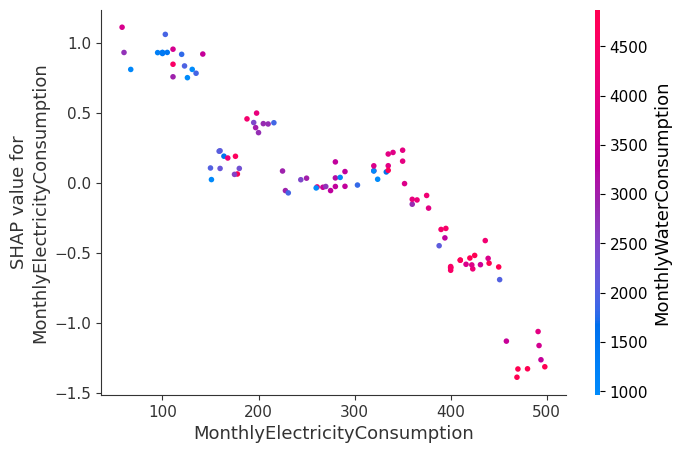

In [69]:
# a more simple version of code above

# For multi-class problems, shap_values is typically a list: one array per class
# We'll select the array for the class of interest
class_idx = 4  # target class index

shap_interaction_values_for_class = shap_interaction_values[:, :, :, class_idx]
shap_values_class = np.diagonal(shap_interaction_values_for_class, axis1=1, axis2=2)

# Plot SHAP dependence using the built-in function
shap.dependence_plot(
    ind=feature_1,
    shap_values=shap_values_class,
    features=X_test,
    interaction_index=feature_2
)

In [70]:
# based on correlations, it seems both water and electricity 
# affect negatively to Rating (makes sense)
# more water and electricity used => worse rating
df.corr()['Rating'].sort_values(ascending=False)

Rating                               1.000000
EnvironmentalAwareness               0.589104
PhysicalActivities                   0.537823
SustainableBrands                    0.512563
CommunityInvolvement                 0.507959
LocalFoodFrequency                   0.506333
DisposalMethods_Composting           0.375585
Gender_Female                        0.328322
TransportationMode_Bike              0.224707
Location_Suburban                    0.186580
DisposalMethods_Combination          0.054590
EnergySource_Mixed                   0.052122
HomeType_House                       0.044927
HomeSize                             0.041610
TransportationMode_Public Transit    0.040284
DietType_Balanced                   -0.043269
HomeType_Apartment                  -0.046101
UsingPlasticProducts                -0.062168
Age                                 -0.062691
Location_Urban                      -0.076609
Gender_Non-Binary                   -0.082908
Location_Rural                    

In [71]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
# X = df.drop("Rating", axis=1)

# # have only the target variable here (dependent variable)
# y = df["Rating"]

# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 
  

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, potentially confusing the ML algorithm
# this might be good info when deciding if some variable needs to be removed
vif_data

,feature,VIF
0,Age,1.252037
1,LocalFoodFrequency,1.678292
2,HomeSize,1.299482
3,ClothingFrequency,1.775994
4,SustainableBrands,1.779904
5,EnvironmentalAwareness,1.870813
6,CommunityInvolvement,1.754424
7,MonthlyElectricityConsumption,2.041684
8,MonthlyWaterConsumption,1.837391
9,UsingPlasticProducts,1.433357


In [72]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# convert all continuous variables to integer,
# and convert all negative numbers to 0
X_cat = X.astype(int)
X_cat = X_cat.clip(lower=0)

# initialize chi2 and SelectKBest
# Note: chi2 -test is a very common test
# in statistics and quantitative analysis
# basically it studies the data whether variables are related
# or independent of each other
chi_2_features = SelectKBest(chi2, k=len(X_cat.columns))

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X_cat,y.astype(int))

# use decimal format in table print later
pd.options.display.float_format = '{:.2f}'.format

# wrap it up, and show the results
# the higher the score, the more effect that column has on price
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X_cat.columns)
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

,Features,Score
8,MonthlyWaterConsumption,77111.66
7,MonthlyElectricityConsumption,8158.83
2,HomeSize,2032.81
28,DisposalMethods_Landfill,162.26
17,TransportationMode_Car,156.61
20,EnergySource_Non-Renewable,130.97
15,DietType_Mostly Animal-Based,127.87
6,CommunityInvolvement,124.16
10,PhysicalActivities,122.53
1,LocalFoodFrequency,103.87


<Axes: >

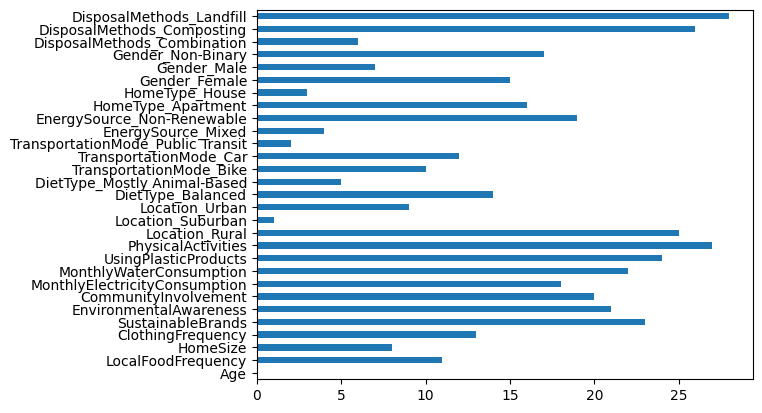

In [73]:
# pip install skfeature-chappers
from skfeature.function.similarity_based import fisher_score

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# how to interpret -> low score means the effect of this field is not large in the dataset
# => typically means other columns in the dataset have similar correlations, 
# therefore making this particular column not so useful since other columns 
# already fill this role for this correlation

# Fisher's score studies the variance of the data -> statistical significance